# Load in open beam and sample images from SciTiff

In [1]:
%matplotlib widget

In [2]:
import scipp as sc
import scitiff

sample_da = scitiff.load_scitiff("sample_data/sample_5e11_mcstas.tiff")['image'].astype(int)
display(sample_da)
openbeam_da = scitiff.load_scitiff("sample_data/open_beam_5e11_mcstas.tiff")['image'].astype(int)
display(openbeam_da)

<scipp.DataArray>
Dimensions: Sizes[t:500, y:100, x:100, ]
Coordinates:
* sample_position           vector3              [m]  ()  (0.026, 0, 60.5)
* source_position           vector3              [m]  ()  (0, 0, 0)
* tof                       float64              [s]  (t [bin-edge])  [0.0153455, 0.015584, ..., 0.134343, 0.134581]
* x                         float64              [m]  (x)  [-0.12375, -0.12125, ..., 0.12125, 0.12375]
* y                         float64              [m]  (y)  [-0.2475, -0.2425, ..., 0.2425, 0.2475]
  z                         float64              [m]  ()  60.5
Data:
                              int64         [counts]  (t, y, x)  [0, 0, ..., 0, 3]

<scipp.DataArray>
Dimensions: Sizes[t:500, y:100, x:100, ]
Coordinates:
* sample_position           vector3              [m]  ()  (0.026, 0, 60.5)
* source_position           vector3              [m]  ()  (0, 0, 0)
* tof                       float64              [s]  (t [bin-edge])  [0.0153455, 0.015584, ..., 0.134343, 0.134581]
* x                         float64              [m]  (x)  [-0.12375, -0.12125, ..., 0.12125, 0.12375]
* y                         float64              [m]  (y)  [-0.2475, -0.2425, ..., 0.2425, 0.2475]
  z                         float64              [m]  ()  60.5
Data:
                              int64         [counts]  (t, y, x)  [0, 0, ..., 1, 4]

# Normalize data

Normalize sample image by open beam and replace 0 counts in OB with 1 to avoid NaN's

In [3]:
from ess.imaging.normalize import (
    apply_threshold_to_background_image,
    apply_threshold_to_sample_images,
)

sample_threshold = apply_threshold_to_sample_images(samples=sample_da, sample_threshold=sc.scalar(0, unit="counts"))
openbeam_threshold = apply_threshold_to_background_image(background=openbeam_da, background_threshold=sc.scalar(1, unit="counts"))
normalized = sample_threshold / openbeam_threshold
normalized

<scipp.DataArray>
Dimensions: Sizes[t:500, y:100, x:100, ]
Coordinates:
* sample_position           vector3              [m]  ()  (0.026, 0, 60.5)
* source_position           vector3              [m]  ()  (0, 0, 0)
* tof                       float64              [s]  (t [bin-edge])  [0.0153455, 0.015584, ..., 0.134343, 0.134581]
* x                         float64              [m]  (x)  [-0.12375, -0.12125, ..., 0.12125, 0.12375]
* y                         float64              [m]  (y)  [-0.2475, -0.2425, ..., 0.2425, 0.2475]
  z                         float64              [m]  ()  60.5
Data:
                            float64  [dimensionless]  (t, y, x)  [0, 0, ..., 0, 0.75]

Plot the normalized image with more tick labels to better identify sample region

In [4]:
import numpy as np

In [5]:
fig = normalized.mean('t').plot(aspect='auto', title="Normalized Image", grid=True)
fig.ax.set_xticks(np.linspace(0.1,-0.1,9))
fig.ax.set_yticks(np.linspace(0.2,-0.2,9))

In [6]:
fig

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

## Region Of Interest (ROI) selector

In [7]:
from scitiff_helper import make_rectangle_tool
roi_container = set()

Rename "t" dimension to "tof" because Scipp workflow requires it to be called "tof"

In [8]:
normalized_renamed = normalized.rename_dims({'t': "tof"})

In the widget below, choose the empty white box at the bottom left and drag and drop to define your ROI.

In [9]:
make_rectangle_tool(normalized_renamed, roi_container=roi_container)

HBar(children=(InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(…

Extract the defined ROI

In [11]:
ROI=roi_container.pop()

### Plot the ROI and its spectrum

Slice the normalized image with the defined ROI

In [12]:
normalized_roi = ROI.slice_dataarray(normalized_renamed)

Plot the sliced image to ensure it is correct

In [26]:
normalized_roi.mean('tof').plot(
    aspect='auto', title='Normalized Region of interest', grid=True
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

Plot the spectrum of the ROI

In [14]:
normalized_roi.mean('x').mean('y').plot(
    aspect='equal', title='Full Spectrum of normalized ROI', grid=True
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

## Convert time-of-flight to wavelength using scippneutron

First, define the conversion graph

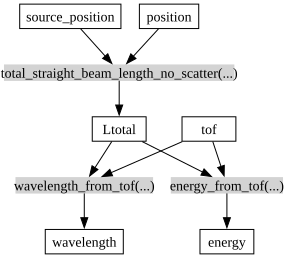

In [15]:
from scippneutron.conversion import graph

PLAIN_GRAPH = {**graph.beamline.beamline(False), **graph.tof.kinematic("tof")}
sc.show_graph(PLAIN_GRAPH)

Then, add the flight-path because it isn't present in the SciTiff

In [20]:
normalized_roi_renamed = normalized_roi.copy(deep=False)
normalized_roi_renamed.coords['Ltotal'] = sc.scalar(60.5, unit='m')
wavelength_transformed = normalized_roi_renamed.transform_coords('wavelength', graph=PLAIN_GRAPH)

In [21]:
wavelength_transformed.mean('x').mean('y').plot(
    aspect='equal', title='Full Spectrum of ROI in wavelength', grid=True
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

## Cut off lower and upper bounds of spectrum

In [22]:
lower_bound = 1.5 * sc.Unit('Å')
upper_bound = 5.0 * sc.Unit('Å')

In [23]:
sliced_spectrum = wavelength_transformed.mean('x').mean('y')['wavelength', lower_bound:upper_bound]

In [24]:
sliced_spectrum.plot(aspect='equal', title='Sliced Spectrum of ROI in wavelength', grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

Get the transmission and wavelengths for fitting

In [25]:
wavelengths = sc.midpoints(sliced_spectrum.coords['wavelength']).values
transmissions = sliced_spectrum.values

# Physical model with Ncrystal

## Inspecting the model

In [27]:
import NCrystal
import NCrystal.plot
import matplotlib.pyplot as plt

In [28]:
# We initalize the model
mat = NCrystal.NCMATComposer()

In [29]:
# We set the model parameters to Iron (slightly off on purpose)
mat.set_cellsg_cubic(2.90)
mat.set_atompos([   ('Fe',0,0,0),
                    ('Fe',0.5, 0.5, 0.5),
                    ])
mat.set_dyninfo_debyetemp("Fe", debye_temp=356)
mat.set_default_temperature(250)
mat.refine_crystal_structure(quiet=True)

In [30]:
scatter = mat.load(#cfg_params="comp=inelas"
                    )

----------------------------------------------------------------------------------------------------
------------------------------------   NCrystal Material Info   ------------------------------------
----------------------------------------------------------------------------------------------------
Data source: <anonymous-ncmat-data>
----------------------------------------------------------------------------------------------------
Density : 7.60478 g/cm3, 0.0820042 atoms/Aa^3
----------------------------------------------------------------------------------------------------
Composition (by mole): 100% Fe
----------------------------------------------------------------------------------------------------
Composition (by mass): 100% Fe
----------------------------------------------------------------------------------------------------
Atom data:
   Fe = Fe(cohSL=9.45fm cohXS=11.2221barn incXS=0.4barn absXS=2.56barn mass=55.8472u Z=26)
-----------------------------------------------

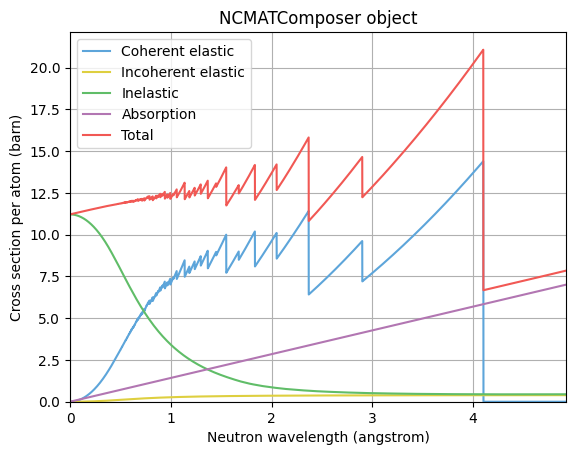

In [32]:
# Information about the model can be viewed with this method
mat.inspect()

In [33]:
# And a short summary can be viewed by printing
print(mat())

NCMAT v7
# Autogenerated by NCMATComposer
#
# Fe (cubic, SG-229)
#
# Atoms per unit cell: 2xFe
#
# NOTICE: crystal structure was verified with spglib to be self-consistent.
#
@CELL
  cubic 2.9
@SPACEGROUP
  229
@ATOMPOSITIONS
  Fe 0 0 0
  Fe 1/2 1/2 1/2
@TEMPERATURE
  default 250
@DYNINFO
  element Fe
  fraction 1
  type vdosdebye
  debye_temp 356



### Comparing Data sets and initial model

Calculating the simulated spectrum using this model

In [44]:
scatter = mat.load(#cfg_params="comp=inelas"
                    )
absorptions = scatter.absorption.xsect(wl=wavelengths)
scattered = scatter.scatter.xsect(wl=wavelengths)
# Using an arbitrary scale constant of 0.05 to scale cross sections and absorptions. Depends on width of material in a real model.
simulated = np.exp(-0.1*(absorptions+scattered))

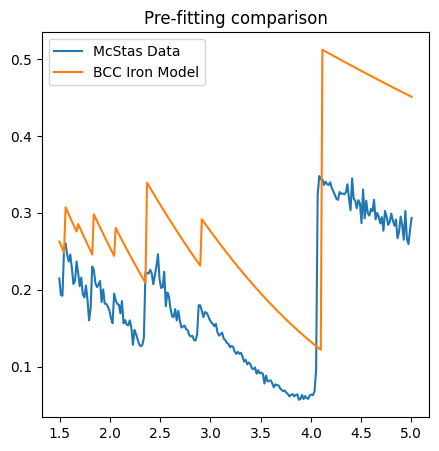

In [45]:
plt.figure(figsize=(5,5))
plt.plot(wavelengths, transmissions, label='McStas Data')
#plt.plot(wavelengths, transmissions, label="Data")
plt.plot(wavelengths, simulated, label="BCC Iron Model")
plt.title("Pre-fitting comparison")
plt.legend()
plt.show()

# Bragg-edge fitting with Ncrystal and EasyScience

In [46]:
from easyscience.Objects.variable import Parameter
from easyscience.Objects.ObjectClasses import BaseObj
from easyscience.fitting import Fitter

## Setting up the fitting models

Defining the fitting parameters and their initial values

In [47]:
lattice_constant =  Parameter(name="Lattice constant",          value=2.85, unit="angstrom",    min=0,  max=4,    fixed=False)
debye_temperature = Parameter(name="Debye temperature",         value=300,  unit="kelvin",      min=250,  max=800,  fixed=False)
temperature =       Parameter(name="Temperature",               value=300,  unit="kelvin",      min=0,  max=600,  fixed=False)
intensity_scale =   Parameter(name="Intensity scale factor",    value=0.15,                      fixed=False)

Defining the fit functions to go into EasyScience

In [48]:
def iron_bragg(wavelength):
    # Initalize the NCrystal material composer
    material = NCrystal.NCMATComposer()
    # Set the material parameters with the fitting variables
    material.set_cellsg_cubic(lattice_constant.value)
    material.set_atompos([  ('Fe',0,0,0),
                            ('Fe',0.5, 0.5, 0.5),
                            ])
    material.set_dyninfo_debyetemp("Fe", debye_temp=debye_temperature.value)
    material.set_default_temperature(temperature.value)

    # Identify the space group from atomic positions
    material.refine_crystal_structure(quiet=True)

    #print("lattice constant:", lattice_constant.value)
    scatter = material.load()

    # Create scattering spectrum
    spectrum = np.exp(-intensity_scale.value*(scatter.scatter.xsect(wl=wavelength) + scatter.absorption.xsect(wl=wavelength)))
    return spectrum

Make the EasyScience container for the fitting parameters

In [49]:
iron_spectrum = BaseObj(
                        name='Iron transmission spectrum', 
                        lattice_constant=lattice_constant, 
                        debye_temperature=debye_temperature,
                        temperature=temperature,
                        intensity_scale=intensity_scale,
                        )

## Fitting

Make the EasyScience fitting objects

In [50]:
fitter = Fitter(iron_spectrum, iron_bragg)

EasyScience can fit data with a variety of different minimizers. To list the available methods, use the "available_minimizers" method:

In [51]:
fitter.available_minimizers

['LMFit',
 'LMFit_leastsq',
 'LMFit_powell',
 'LMFit_cobyla',
 'LMFit_differential_evolution',
 'LMFit_scipy_least_squares',
 'Bumps',
 'Bumps_simplex',
 'Bumps_newton',
 'Bumps_lm',
 'DFO',
 'DFO_leastsq']

For the fits in this notebook, we will use "LMFit_leastsq" which is a standard leastsquares fitting method

In [52]:
fitter.switch_minimizer("LMFit_leastsq")

minimizer should be set with enum LMFit_leastsq


### Performing the actual Fit

In [54]:
# Parameters for LMFit_leastsq
results = fitter.fit(x=wavelengths, y=transmissions, 
                     #weights=1/np.sqrt(transmissions_variances), 
                     minimizer_kwargs={"epsfcn":0.005,
                                       "ftol":1.49012e-15,
                                       "xtol":1.49012e-15,
                                       },
                    #max_nfev=10000
                     )

Print the fitted values

In [55]:
print(lattice_constant)
print(debye_temperature)
print(temperature)
print(intensity_scale)

<Parameter 'Lattice constant': 2.8756 ± 0.0023 Å, bounds=[0.0:4.0]>
<Parameter 'Debye temperature': 312.8107 ± 24.2190 K, bounds=[250.0:800.0]>
<Parameter 'Temperature': 599.8988 ± 45.4771 K, bounds=[0.0:600.0]>
<Parameter 'Intensity scale factor': 0.1352 ± 0.0009, bounds=[-inf:inf]>


## Comparing the fitted model and data

First we need to calculate the spectras with the fitted models

In [56]:
simulated = iron_bragg(wavelengths)

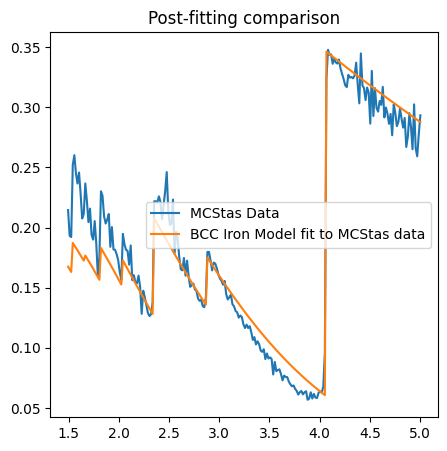

In [57]:
plt.figure(figsize=(5,5))
plt.plot(wavelengths, transmissions, label='MCStas Data')
plt.plot(wavelengths, simulated, label="BCC Iron Model fit to MCStas data")
plt.title("Post-fitting comparison")
plt.legend()
plt.show()